# 04 · Is music converging to a formula?

**The question:** people say 'everything sounds the same now.' If true, the *spread* of audio features within a year should shrink over time. Let's measure — and picture — it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
df = load_timeline()
zdf = pd.DataFrame(zscore(df), columns=AUDIO).assign(year=df.year.values)
disp = zdf.groupby('year')[AUDIO].std().mean(axis=1)
print(f'dispersion 1960: {disp.loc[1960]:.3f} · 2000: {disp.loc[2000]:.3f} · 2020: {disp.loc[2020]:.3f}')

dispersion 1960: 0.984 · 2000: 0.885 · 2020: 0.851


## Step 1 — Average feature spread per year
Mean standard deviation across the 9 (standardized) features. Lower = more homogeneous. Note the step-down shaded from 2000 on.

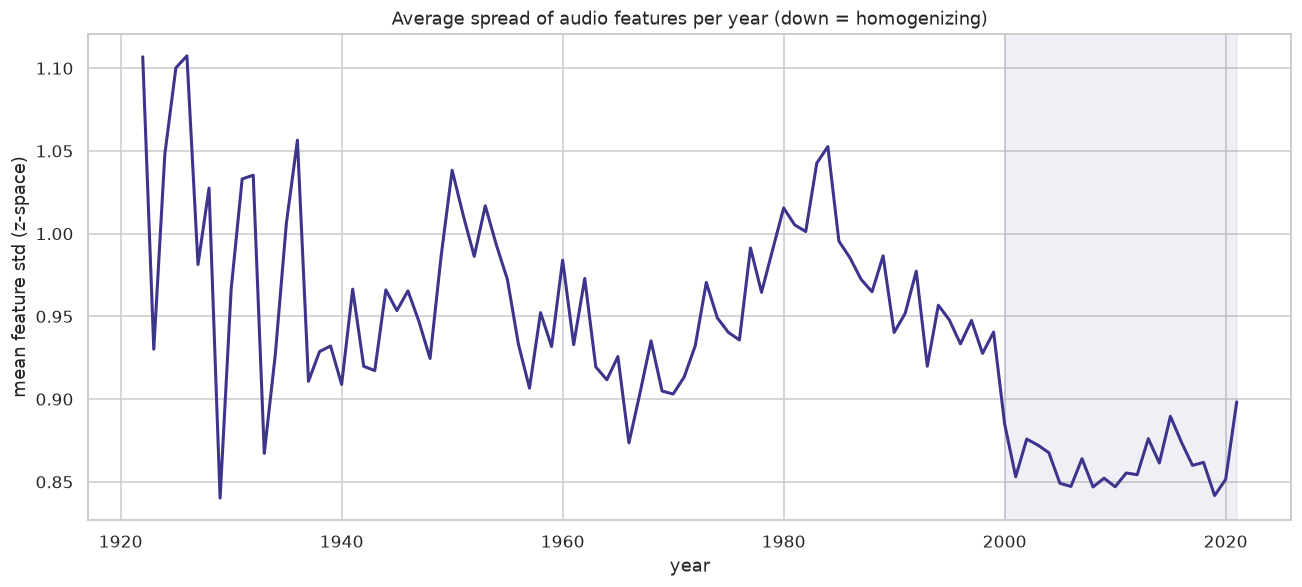

In [2]:
plt.figure(figsize=(12, 5.5))
plt.plot(disp.index, disp.values, color='#3d348b', lw=2)
plt.axvspan(2000, disp.index.max(), color='#3d348b', alpha=.08)
plt.title('Average spread of audio features per year (down = homogenizing)')
plt.xlabel('year'); plt.ylabel('mean feature std (z-space)'); plt.tight_layout(); plt.show()

## Step 2 — Which features are converging? (small multiples)
Spread *per feature* per year. Not everything narrows equally — some features homogenize much more than others.

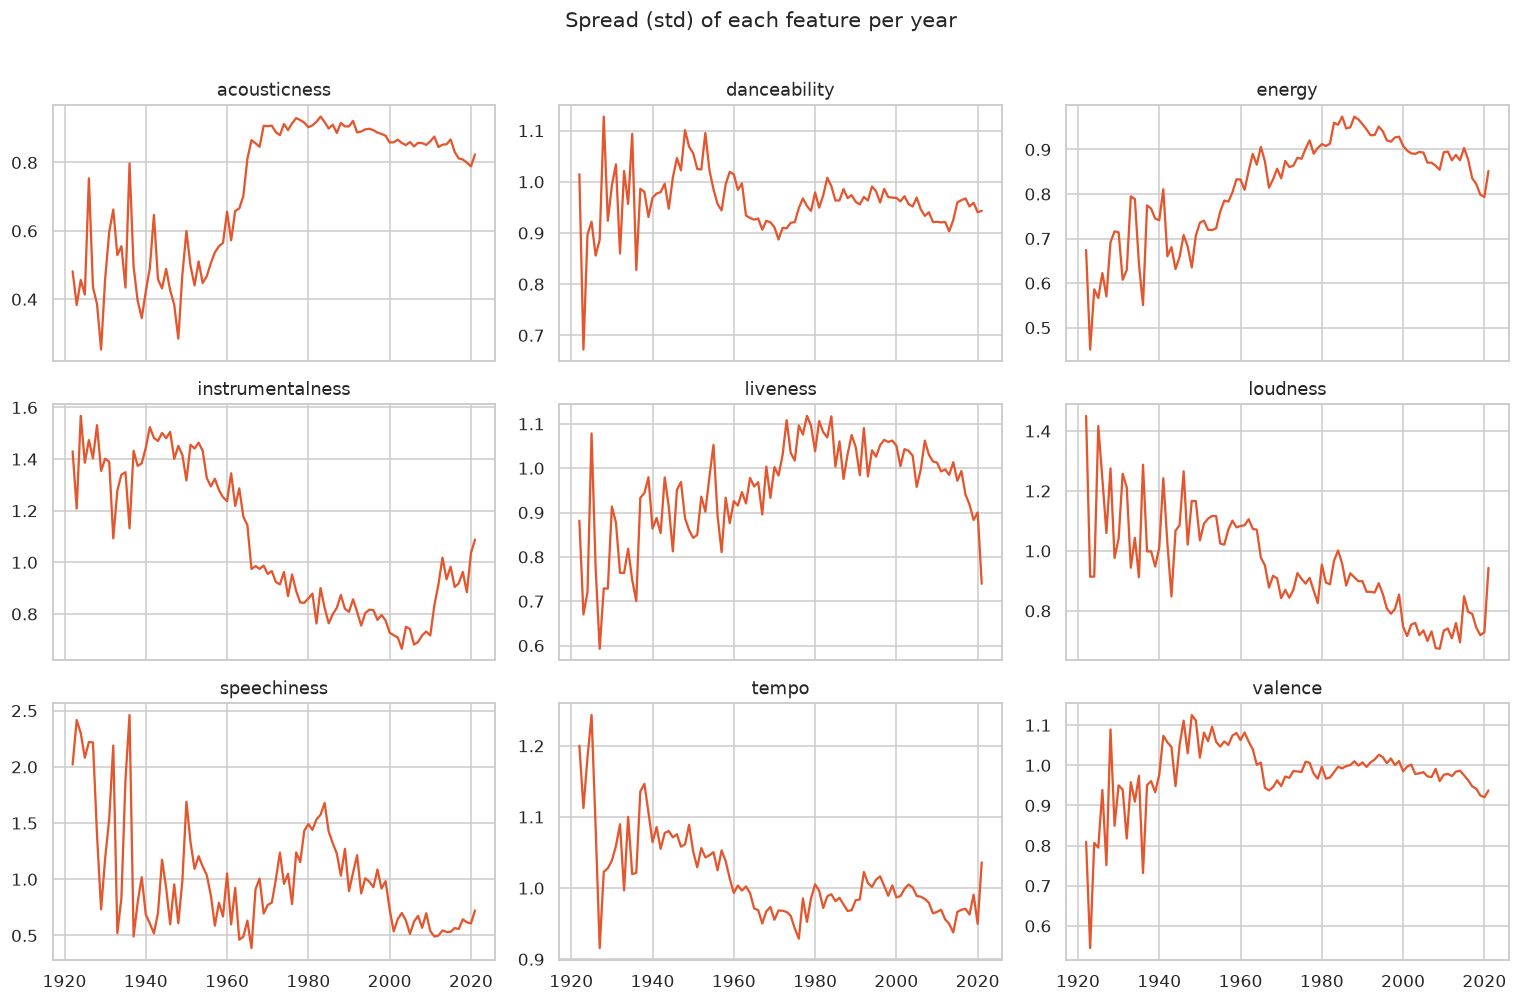

In [3]:
sd = zdf.groupby('year')[AUDIO].std()
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True)
for ax, f in zip(axes.ravel(), AUDIO):
    ax.plot(sd.index, sd[f], color='#e4572e'); ax.set_title(f)
fig.suptitle('Spread (std) of each feature per year', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## Step 3 — See the narrowing directly
The full distribution of *every* feature by decade. `acousticness` collapses toward the low end as electronic production takes over; several others (energy, loudness, danceability) shift and tighten too — a concrete, distribution-level picture of the homogenization above.

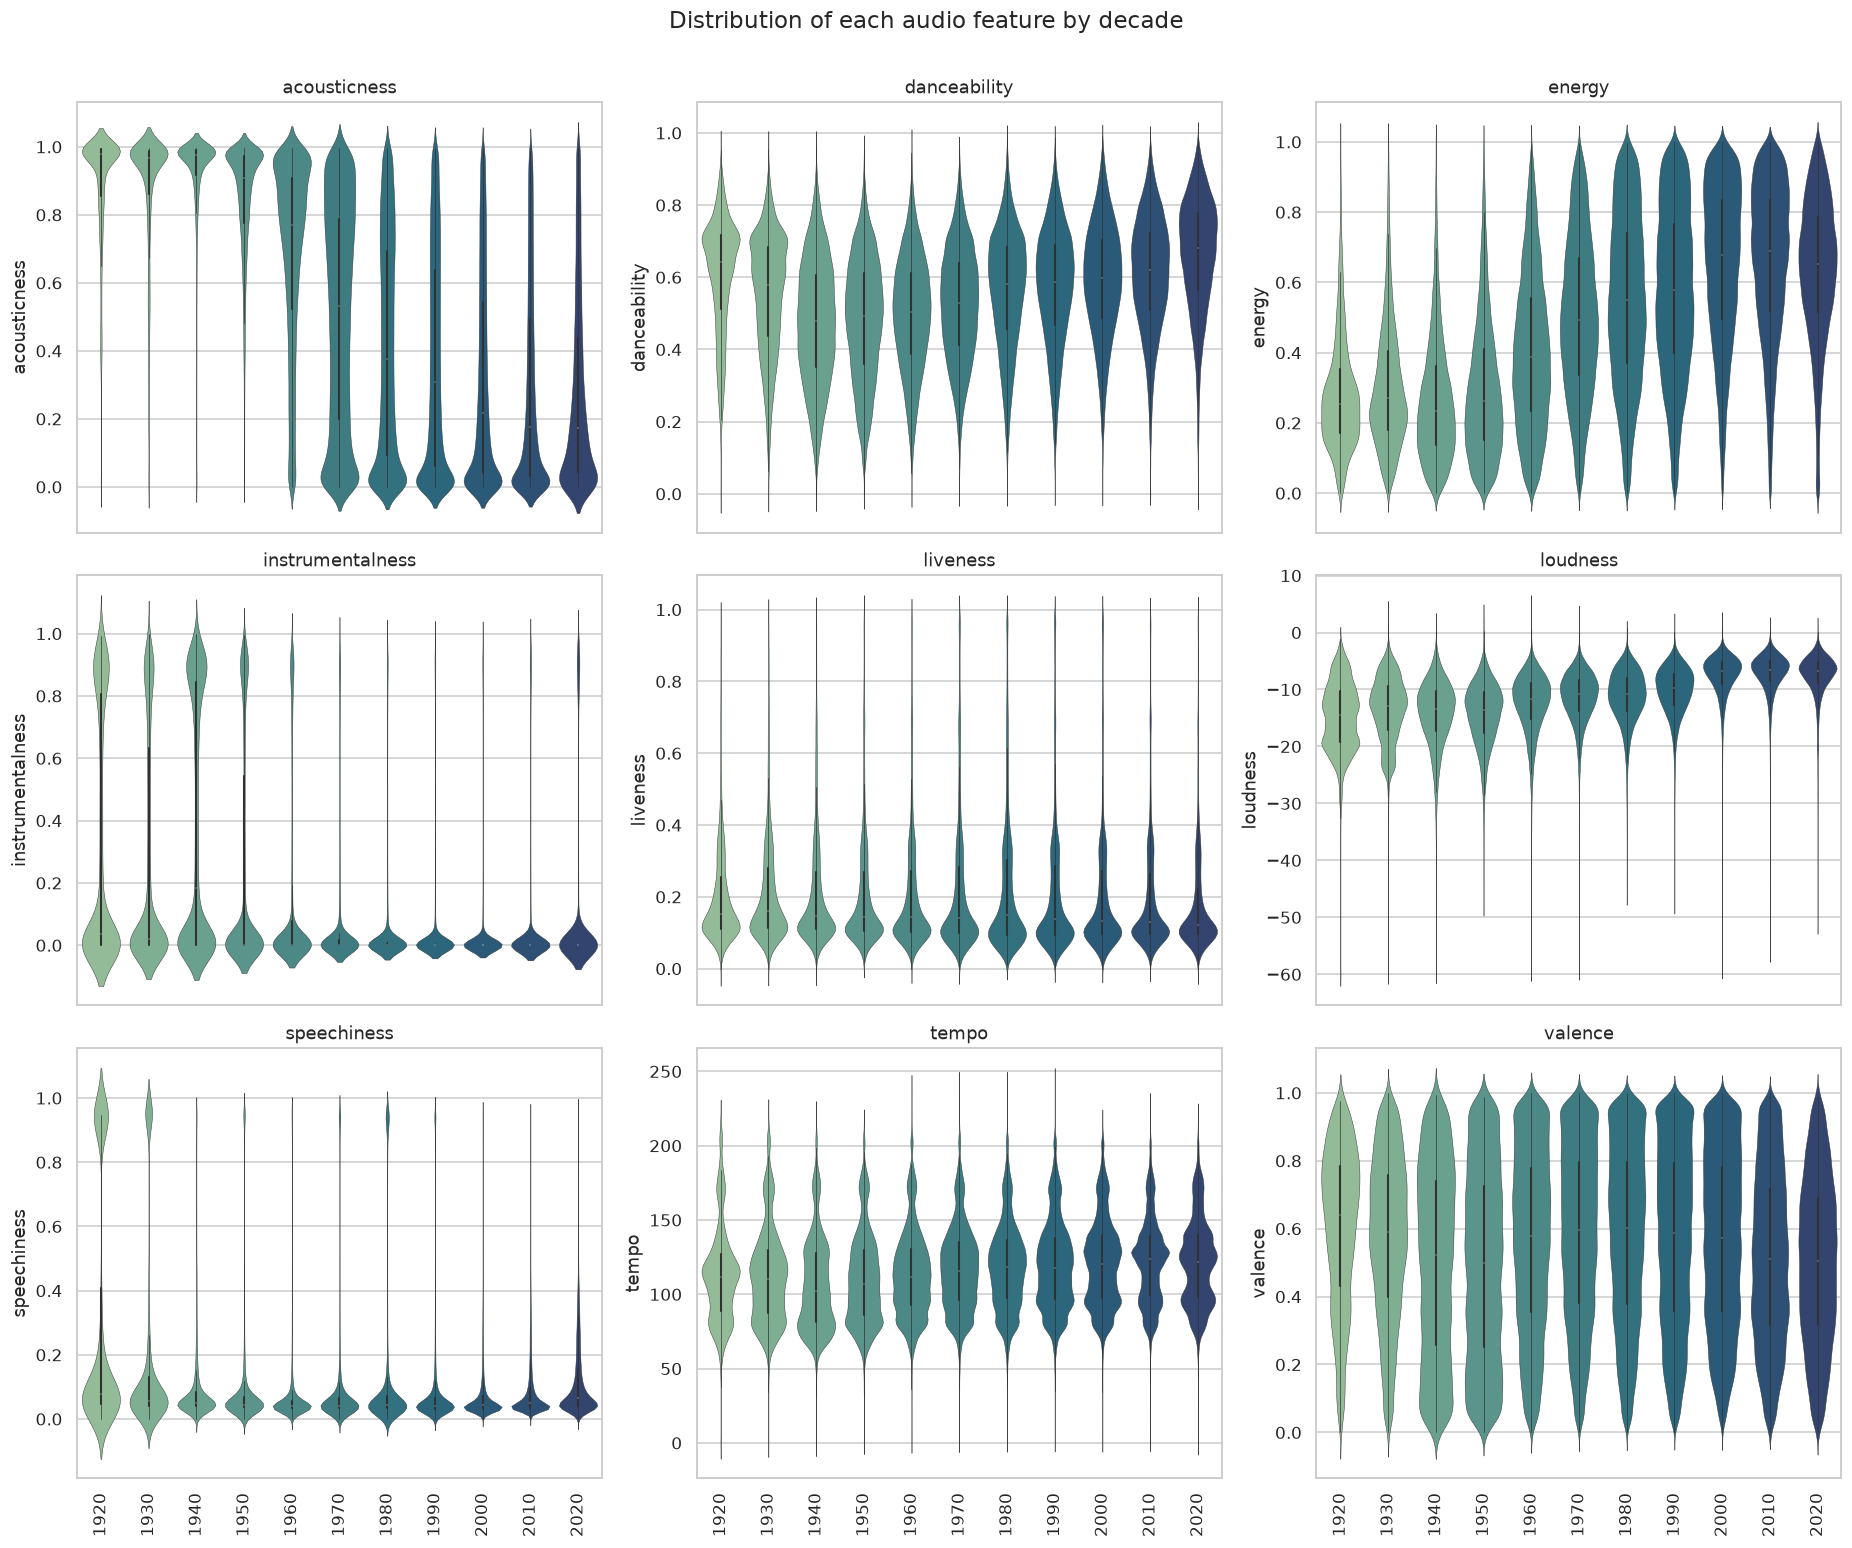

In [4]:
dv = df.assign(decade=df.decade.astype(str))
order = [str(d) for d in sorted(df.decade.unique())]
fig, axes = plt.subplots(3, 3, figsize=(17, 14), sharex=True)
for ax, f in zip(axes.ravel(), AUDIO):
    sns.violinplot(dv, x='decade', y=f, order=order, ax=ax, hue='decade', hue_order=order,
                   legend=False, density_norm='width', linewidth=.3, palette='crest')
    ax.set_title(f); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=90)
fig.suptitle('Distribution of each audio feature by decade', y=1.004, fontsize=15)
plt.tight_layout(); plt.show()

## Step 4 — Fewer *archetypes*? (the multivariate view)
Per-feature spread shrinking doesn't prove there are fewer *kinds* of music — features could recombine in just as many ways. So we look at the **joint** distribution, three ways, per decade. Each decade is subsampled to the same N so 'diversity' isn't just an artifact of the catalog growing:

- **Effective # of archetypes** — cluster the sound-space into 24 prototype sounds, then take the *perplexity* (exp-entropy) of how a decade's tracks spread across them. Higher = more kinds.
- **Effective dimensionality** — participation ratio of the decade's covariance: how many independent 'style axes' music varies along.
- **Mean radius** — average distance from the decade's centroid: overall spread.

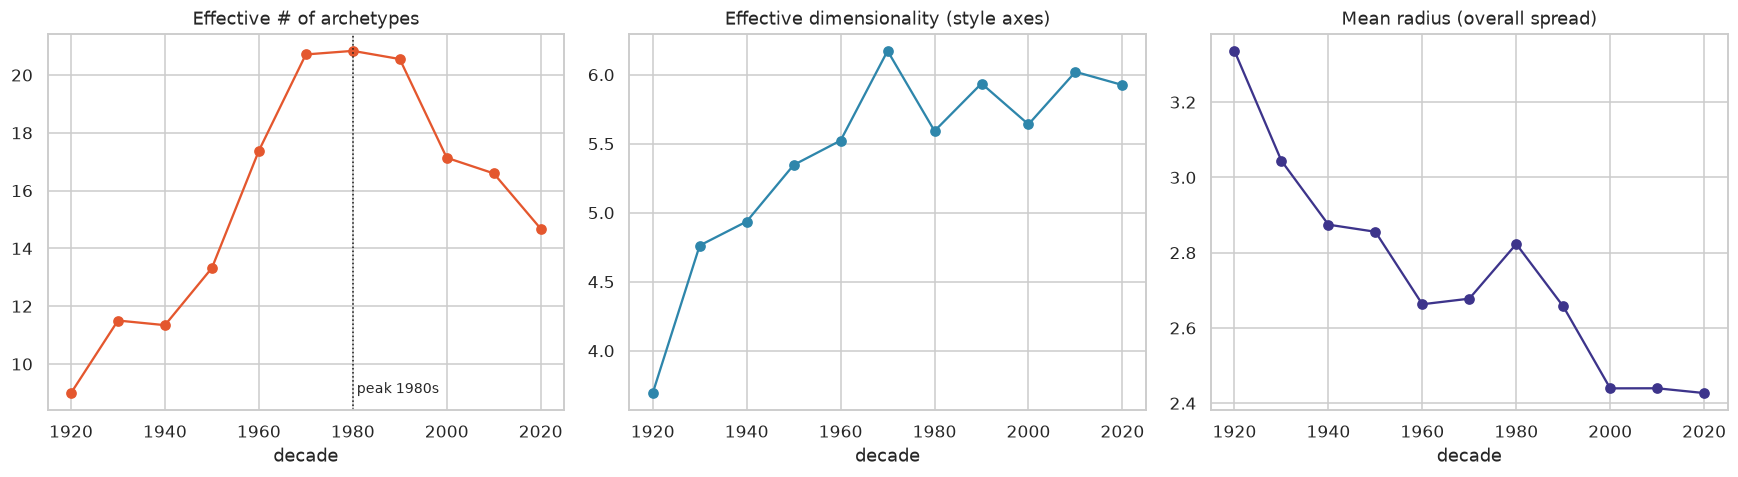

,archetypes,eff_dim,radius
decade,,,
1920,8.99,3.69,3.34
1930,11.50,4.76,3.04
1940,11.34,4.94,2.87
1950,13.32,5.35,2.86
1960,17.38,5.52,2.66
1970,20.71,6.17,2.68
1980,20.83,5.59,2.82
1990,20.55,5.94,2.66
2000,17.14,5.64,2.44


In [5]:
from sklearn.cluster import KMeans
Xs = zscore(df); dec = df['decade'].to_numpy()
lab = KMeans(n_clusters=24, n_init=5, random_state=42).fit_predict(Xs)
decades = sorted(np.unique(dec)); N = min((dec==d).sum() for d in decades)
rng = np.random.default_rng(0)
def perplexity(idx):
    p = np.bincount(lab[idx], minlength=24)/len(idx); p = p[p>0]
    return np.exp(-(p*np.log(p)).sum())
rows = []
for d in decades:
    pool = np.where(dec==d)[0]; ea=[]; pr=[]; rad=[]
    for _ in range(8):
        s = rng.choice(pool, N, replace=False)
        ea.append(perplexity(s))
        ev = np.linalg.eigvalsh(np.cov(Xs[s].T)); ev = ev[ev>0]
        pr.append(ev.sum()**2/(ev**2).sum())
        rad.append(np.linalg.norm(Xs[s]-Xs[s].mean(0), axis=1).mean())
    rows.append((d, np.mean(ea), np.mean(pr), np.mean(rad)))
m = pd.DataFrame(rows, columns=['decade','archetypes','eff_dim','radius']).set_index('decade')
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, col, ttl, c in [(ax[0],'archetypes','Effective # of archetypes','#e4572e'),
                       (ax[1],'eff_dim','Effective dimensionality (style axes)','#2e86ab'),
                       (ax[2],'radius','Mean radius (overall spread)','#3d348b')]:
    a.plot(m.index, m[col], marker='o', color=c); a.set_title(ttl); a.set_xlabel('decade')
peak = m['archetypes'].idxmax()
ax[0].axvline(peak, color='k', ls=':', lw=1); ax[0].text(peak, m['archetypes'].min(),
              f' peak {peak}s', fontsize=9)
plt.tight_layout(); plt.show()
m.round(2)

**Takeaway:** the number of distinct archetypes traces an **inverted-U** — music *diversified* from ~9 kinds (1920s) to ~21 (1970s–90s), then **consolidated to ~15 by the 2020s.** Effective dimensionality rose then plateaued (~6 axes); overall radius drifted gently down. Recent music isn't lower-dimensional — it **clumps into fewer archetypes** along the same axes.

## Verdict
Two 'homogenization' questions, two answers:
- **Per feature:** spread drifts down modestly, with a step around 2000 (Steps 1–3).
- **In combination:** archetypes *rose* for most of the century, **peaked in the 1970s–90s, and have fallen since ~2000** — fewer *kinds* of song in the streaming era, even though the number of style-axes held steady.

So music didn't simply 'get more samey' — it diversified for decades, then began **consolidating into fewer archetypes**. Caveat: dataset B's early decades are surviving / curated catalog (which can *understate* old diversity), so the **post-1990 decline** — measured on large, fresh catalogs — is the robust part of the story.